# Forecasting Inflation
### **Adam Mendoza**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima.arima import auto_arima

In [4]:
bsp_cpi = pd.read_csv('..//data//bsp_cpibase2018_dataset.csv')
bsp_cpi['Date'] = pd.to_datetime(bsp_cpi['Year'].astype(str) + ' ' + bsp_cpi['Month'] + ' 1')
bsp_cpi.rename(columns={'All Items': 'CPI'}, inplace=True)
bsp_cpi = bsp_cpi[['Date', 'CPI']]
bsp_cpi.set_index('Date', inplace = True)

## **Preamble**
The change in the general level of prices in an economy is quantified through the **inflation rate**. In practice, this is often measured by determining how the **consumer price index** of a typical basket of goods vary in a span of a year. In other words

\begin{align}
I_{\mathrm{YoY}}&=\frac{\mathrm{CPI}_{t}-\mathrm{CPI}_{t-12}}{\mathrm{CPI}_{t-12}}*100\%.
\end{align}

In [5]:
inflation_rate = bsp_cpi['CPI'].pct_change(12) * 100
bsp_cpi['InflationRate'] = inflation_rate
inf = bsp_cpi['InflationRate'].dropna()

bsp_cpi.dropna().head()

,CPI,InflationRate
Date,,
1958-01-01,0.891176,6.25000
1958-02-01,0.891176,6.25000
1958-03-01,0.884623,5.46875
1958-04-01,0.884623,5.46875
1958-05-01,0.891176,6.25000


Check if there are no missing months

In [6]:
freq = pd.infer_freq(inf.index.sort_values())
print(freq)

MS


Plot the data

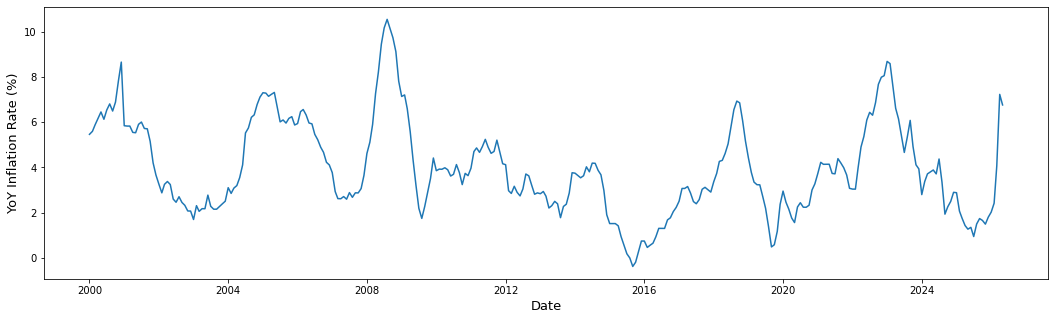

In [7]:
plt.figure(figsize=(18, 5))
plt.plot(inf.loc['2000':])
plt.xlabel('Date', fontsize = 13)
plt.ylabel('YoY Inflation Rate (%)', fontsize = 13)
plt.show()

The plot of the year-on-year inflation rate, which we will simply call *inflation* henceforth, exhibits periods of inflation and disinflation (inflation rate goes down). However, there exists persistent sustained increase which can be explained by local and international events. 

**2004 - 2006** - Global oil price surge and expanded VAT law 

**2008 - 2009** - Global oil price surge and global food price crisis, the former being one of the causes. The consequent sharp dip can be explained by global 

**2016 - 2019** - *Build, Build, Build* leading to an increase in government spending and therefore, demand, amplified by *TRAIN Law* signed in Dec 2019. 

**2020 - 2024** - COVID-19 Pandemic, disrupting supply chains. The steady rise can be explained by decreasing production but increasing demands, resulting into overheat. 

In the current period, we are observing a dramatic rise of inflation due to the ongoing Iran war. In particular, the restrictions in the Strait of Hormuz constricts the global oil supply, leading to another global oil price surge. 

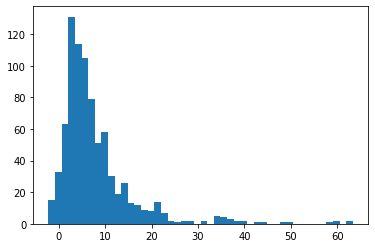

In [8]:
plt.hist(inf, bins = 'fd') # Use the Freedman-Diaconis bin width
plt.show()

The distribution is non-normal with a strong right skewness. The inflation is centered around $5\%$ with occassional extreme inflation events.

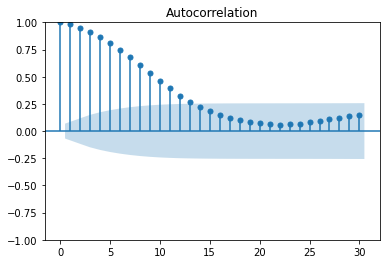

In [9]:
plot_acf(inf)
plt.show()

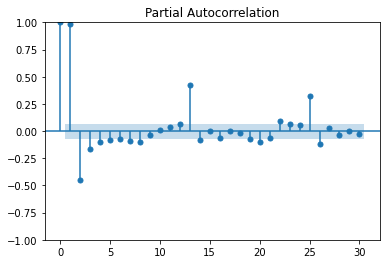

In [10]:
plot_pacf(inf)
plt.show()

# I. Classical forecast: ARIMA


We first have to ensure if our data is stationary. We first use the Augmented Dickey-Fuller test. The null hypothesis, $H_0$, is that the series is **non-stationary**. We reject it when ADF statistic $<$ critical value.

In [11]:
adfuller(inf)

(-4.405822176856041,
 0.00028986881500239845,
 21,
 799,
 {'1%': -3.4385608049885876,
  '5%': -2.865164107438179,
  '10%': -2.5686998068142124},
 2559.2892887467983)

The ADF test statistic is `-4.37`. Since the test statistic is less than the critical values at $1\%$, $5\%$, and $10\%$, we reject the null hypothesis at all levels. In the Kwiatkowski-Phillips-Schmidt-Shin (KPSS), however, the null hypothesis, $H_0$, is that the series is **stationary**. We reject it when KPSS statistic $>$ critical value.

In [12]:
kpss(inf)

C:\Users\PC\AppData\Local\Temp/ipykernel_8632/1038890407.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss(inf)


(0.7668438377492122,
 0.01,
 17,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

The KPSS test statistic is `0.767`. Since the test statistic is greater than the critical values at $1\%$, $5\%$, and $10\%$, we reject the null hypothesis at all levels. These two tests taken together means that stationarity is inconclusive.

In [13]:
months_inc = 24
inf_train = inf[:-int(months_inc)]
inf_test = inf[-int(months_inc):]

In [14]:
sarima_model = auto_arima(inf_train, seasonal=True, m=12) 
print(sarima_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  797
Model:             SARIMAX(1, 1, 2)x(0, 0, [1], 12)   Log Likelihood               -1181.061
Date:                              Sat, 13 Jun 2026   AIC                           2372.122
Time:                                      21:10:00   BIC                           2395.520
Sample:                                  01-01-1958   HQIC                          2381.113
                                       - 05-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8824      0.022     40.104      0.000       0.839       0.926
ma.L1         -0.53

In [15]:
sarima_forecast = sarima_model.predict(n_periods = len(inf_test))
naive_forecast = pd.Series(np.repeat(inf_train.iloc[-1], len(inf_test)), index=inf_test.index)
seasonal_naive_forecast = inf.shift(12).loc[inf_test.index]

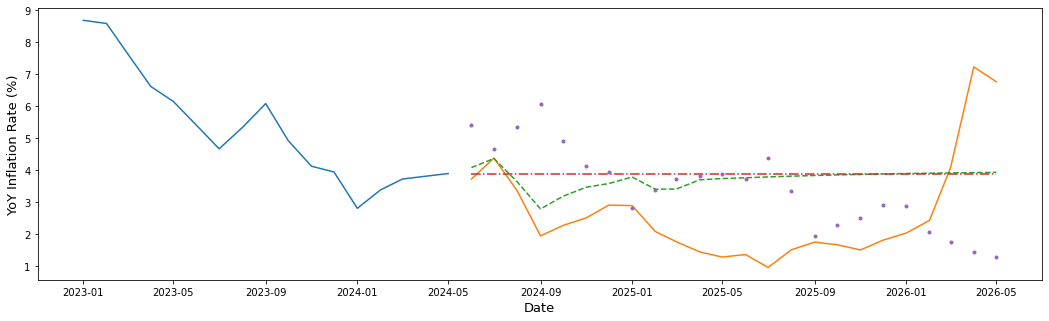

In [16]:
start_date = '2023-01-01'

plt.figure(figsize=(18, 5))
plt.plot(inf_train.loc[start_date:])
plt.plot(inf_test.loc[start_date:])
plt.plot(sarima_forecast.loc[start_date:], '--')
plt.plot(naive_forecast.loc[start_date:], '-.')
plt.plot(seasonal_naive_forecast.loc[start_date:], '.')

plt.xlabel('Date', fontsize = 13)
plt.ylabel('YoY Inflation Rate (%)', fontsize = 13)
plt.show()

In [17]:
comp_forecasts = [sarima_forecast, naive_forecast, seasonal_naive_forecast]
rmse_list = []
for forecast in comp_forecasts:
    mae = mean_absolute_error(inf_test, forecast)
    rmse = np.sqrt(mean_squared_error(inf_test, forecast))
    rmse_list.append(rmse)

print('The RMSE for SARIMA is {:.2f}'.format(rmse_list[0]))
print('The RMSE for Naive is {:.2f}'.format(rmse_list[1]))
print('The RMSE for Seasonal Naive is {:.2f}'.format(rmse_list[2]))

The RMSE for SARIMA is 1.85
The RMSE for Naive is 2.01
The RMSE for Seasonal Naive is 2.47


In [18]:
horizons = [1, 2, 6, 12, 24]

results = []

for h in horizons:
    inf_train = inf.iloc[:-h]
    inf_test = inf.iloc[-h:]

    sarima_model = auto_arima(inf_train, seasonal=True, m=12, suppress_warnings=True)

    sarima_forecast = pd.Series(sarima_model.predict(n_periods=h), index=inf_test.index)

    naive_forecast = pd.Series(np.repeat(inf_train.iloc[-1], h), index=inf_test.index)

    seasonal_naive_forecast = inf.shift(12).loc[inf_test.index]

    sarima_rmse = np.sqrt(mean_squared_error(inf_test, sarima_forecast))
    naive_rmse = np.sqrt(mean_squared_error(inf_test, naive_forecast))
    seasonal_naive_rmse = np.sqrt(mean_squared_error(inf_test, seasonal_naive_forecast))

    results.append({
        "Forecast Horizon": h,
        "SARIMA RMSE": sarima_rmse,
        "Naive RMSE": naive_rmse,
        "Seasonal Naive RMSE": seasonal_naive_rmse
    })

KeyboardInterrupt: 

In [ ]:
rmse_table = pd.DataFrame(results)
rmse_table

,Forecast Horizon,SARIMA RMSE,Naive RMSE,Seasonal Naive RMSE
0,1,2.154368,3.158165,5.792760
1,2,2.956193,3.593494,4.411677
2,6,2.150751,2.501680,2.645992
3,12,1.721714,1.879145,2.414475
4,24,1.702888,1.865910,2.245171


SARIMA outperforms naive forecasts for 1 to 12 month horizons but fails for 24 month horizon. We will now deploy for a forecast for the next six months.

In [19]:
sarima_model_final = auto_arima(inf, seasonal=True, m=12, suppress_warnings=True)
sarima_forecast = pd.Series(sarima_model_final.predict(n_periods=6))
sarima_forecast

2026-06-01    7.036636
2026-07-01    7.390334
2026-08-01    7.378207
2026-09-01    7.795006
2026-10-01    8.106122
2026-11-01    8.447115
Freq: MS, dtype: float64

The forecasted June inflation is $7\%$ and will steadily increase to $8.44\%$ come November.